# Time Series Analysis: ARIMA(p,d,q) approach

## Massimo Facchinutti (148488)

## Introduction 

In many fields of economics, finance and engineering, data are collected sequentially over time, giving rise to what is known as a **time series**. the values of a time series are typically not independent from one another, each observation is influenced by those that preceded it. Understanding and modelling this dependence is the central objective of time series analysis.
Among the most established and widely used tools for this purpose is the **AutoRegressive Integrated Moving Average** (ARIMA) model, introduced by *Box and Jenkins* in *1970*. The ARIMA framework combines three components: an AutoRegressive part, which relates the current value of the series to its own past values, a Moving Average part, which accounts for the influence of past forecast errors and an Integrated part, which addresses the non-stationarity that characterises most real-world economic time series. The systematic procedure through which an ARIMA model is identified, estimated, and validated remains one of the most known and widely adopted approaches in time series analysis.

In this work, we apply this methodology to the empirical analysis of the *Industrial Production Index (IPI)*, a monthly macroeconomic indicator published by the Federal Reserve that measures the real output of the manufacturing, mining and utility sectors of the US economy. 

The analysis is structured as follows. We begin with an exploratory examination of the series, studying its main statistical properties and visual features. We then decompose the IPI into its structural components (trend, seasonality, and residual) and formally assess the stationarity of the data. On the basis of these results, we identify and estimate the most appropriate ARIMA specification, generate an out-of-sample forecast and conclude with a thorough diagnostic analysis of the model residuals.

## 1. Setup & Data Loading


In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import itertools

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})
sns.set_palette("deep")

In [3]:

df = pd.read_csv('INDPRO.csv')

df.columns = ['date', 'ipi']

df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df = df.sort_index()

try:
    df.index.freq = pd.tseries.frequencies.to_offset('MS')
except:
    df.index.freq = pd.tseries.frequencies.to_offset('ME')

df.head()

,ipi
date,
1970-01-01,37.9948
1970-02-01,37.9698
1970-03-01,37.9205
1970-04-01,37.8230
1970-05-01,37.7789


## 2. What is a Time Series?

A **time series** is a set of values, usually collected at regular intervals. Time series data occur naturally in many application areas:

- Economic (monthly data for unemployment, hospital admissions, etc.);
- Finance (daily exchange rate, a share price, etc.);
- Environmental (daily rainfall, air quality readings, etc.);
- Medicine (ECG brain wave activity every 2−8 secs, etc.).



We plot the full IPI series over the entire sample period. The x-axis displays the years intervals, while the y-axis reports the index values.

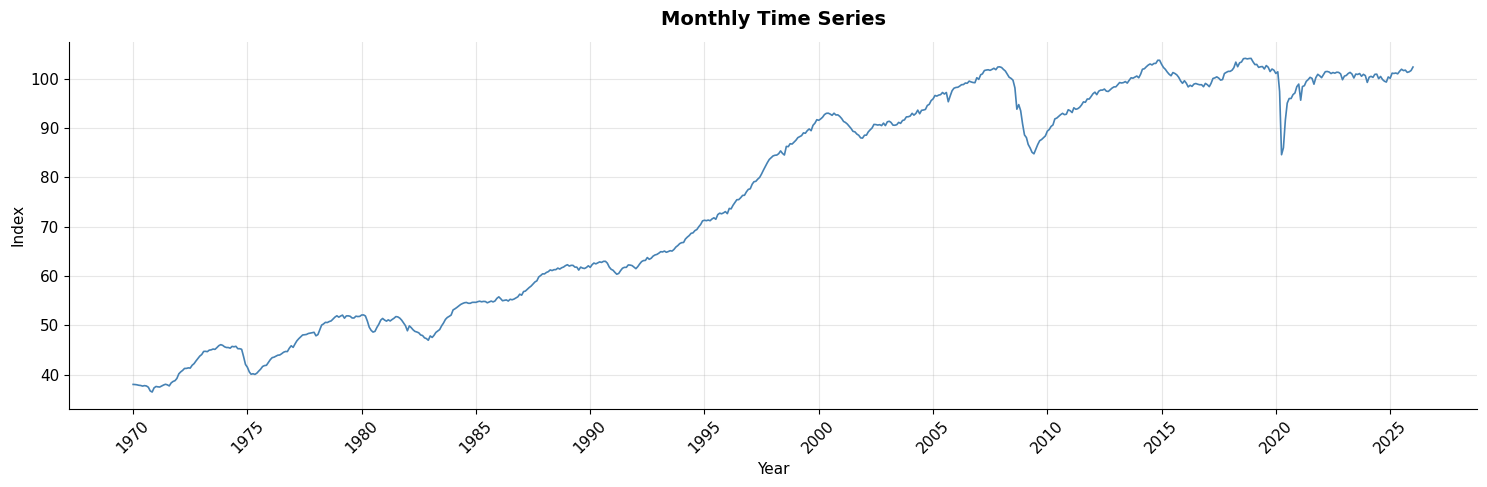

In [4]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df.index, df['ipi'], color='steelblue', linewidth=1.2)
ax.set_title('Monthly Time Series', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Index')
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The series displays a clear and persistent upward **trend** over the sample period, which is consistent with the long-run growth of industrial output driven by technological progress, capital accumulation and the broader expansion of the world economy. Inflationary dynamics and rising price levels over time may also contribute to the upward trajectory of the index in nominal terms.
The trend is, however, interrupted by two particularly sharp and clearly identifiable negative episodes. The first occurs around 2008–2009, coinciding with the Global Financial Crisis, which triggered a severe contraction in industrial activity across all major sectors. The second takes place in 2020 and is directly attributable to the COVID-19 pandemic, which caused an unprecedented sudden halt in production followed by a rapid recovery.
Regarding the other components of the series, no strong **seasonal pattern** is immediately apparent from the raw plot, suggesting that any seasonal fluctuations present in the data are of relatively modest magnitude compared to the dominant trend. The **cyclical component**, by contrast, is more difficult to assess visually, as it tends to overlap with the trend and can only be properly isolated through formal decomposition techniques, which will be carried out in the following section.

We now apply **Moving Average** models on the original IPI series. A moving average is a statistical technique used to smooth a time series by replacing each observation with the average of a fixed number of surrounding values. Its primary purpose is to filter out short-term fluctuations (such as seasonal oscillations or random noise) in order to reveal the underlying trend or longer-run dynamics of the series more clearly. Secondly, we display the year-over-year percentage change of the index, computed as the percentage difference between each monthly observation and the corresponding observation twelve months earlier. This representation removes the trend from the picture and focuses attention on the growth rate of industrial production.

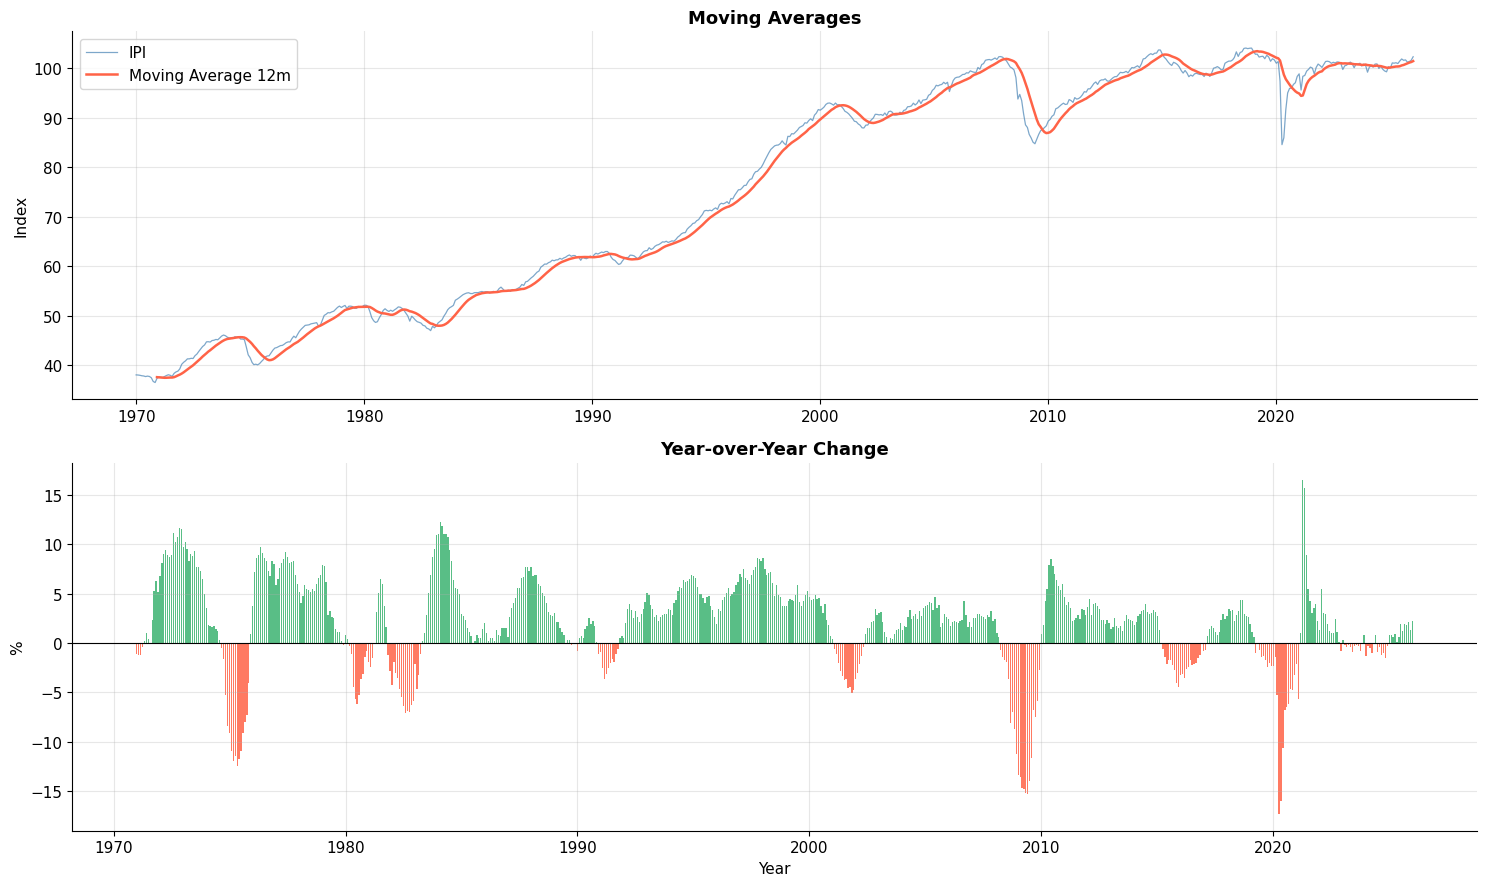

In [5]:
df['yoy_change'] = df['ipi'].pct_change(12) * 100
df['ma_12']      = df['ipi'].rolling(window=12).mean()

fig, axes = plt.subplots(2, 1, figsize=(15, 9))

axes[0].plot(df.index, df['ipi'],    color='steelblue',  linewidth=0.9, alpha=0.7, label='IPI')
axes[0].plot(df.index, df['ma_12'],  color='tomato',     linewidth=1.8, label='Moving Average 12m')
axes[0].set_title('Moving Averages', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Index')
axes[0].legend()

axes[1].bar(df.index, df['yoy_change'],
            color=['tomato' if x < 0 else 'mediumseagreen' for x in df['yoy_change']],
            width=20, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Year-over-Year Change', fontsize=13, fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_xlabel('Year')

plt.tight_layout()
plt.show()

The upper panel confirms the presence of a strong and persistent upward trend in the IPI throughout the sample period. The lower panel reinforces these observations through the year-over-year growth rate.

The following code plots the overall distribution of all IPI observations over the sample period. The histogram divides the range of IPI values into equally spaced bars and displays the relative frequency of observations falling into each bar. 

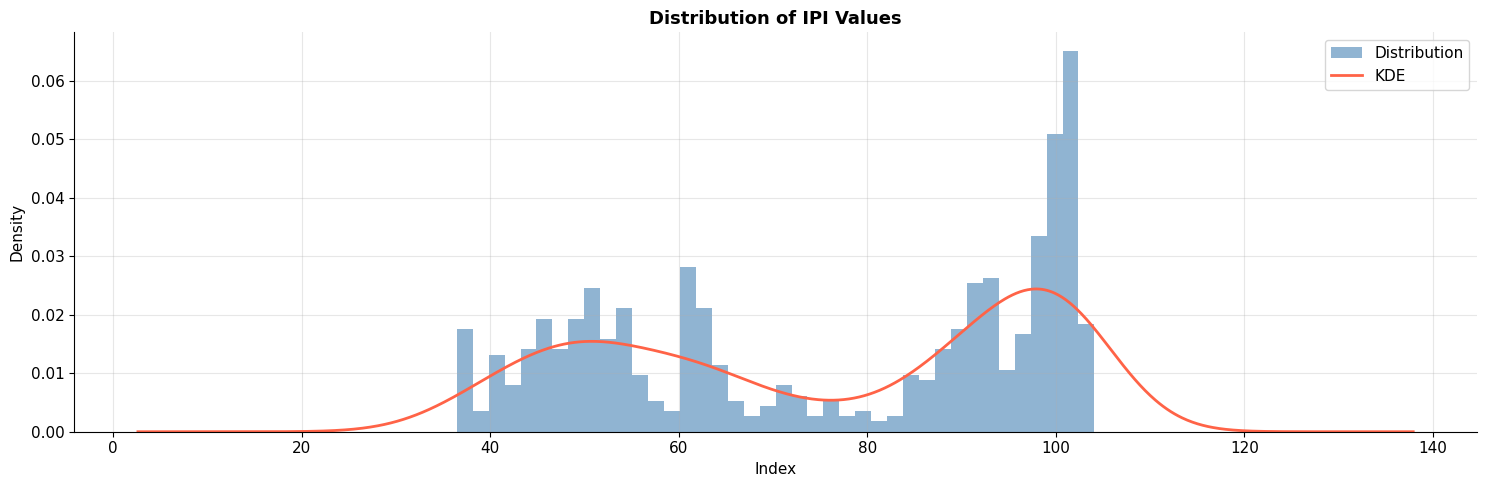

In [5]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.hist(df['ipi'].dropna(), bins=40, color='steelblue', alpha=0.6, density=True, label='Distribution')
df['ipi'].dropna().plot(kind='kde', ax=ax, color='tomato', linewidth=2, label='KDE')
ax.set_title('Distribution of IPI Values', fontsize=13, fontweight='bold')
ax.set_ylabel('Density')
ax.set_xlabel('Index')
ax.legend()

plt.tight_layout()
plt.show()

The curve displays a **bimodal distribution**, meaning it has two distinct peaks rather than one. It is a direct consequence of the strong upward trend present in the series. If we were to remove the trend and look at the distribution of the detrended series, we would likely obtain a much more symmetric and unimodal distribution. 

## 3. Series Decomposition

In this section we decompose the IPI series into its three fundamental structural components: **trend**, **seasonal component** and the **residual component**, which represents the irregular variation left after the trend and seasonality have been removed. Decomposing a time series is a fundamental preliminary step in time series analysis, as it allows us to understand the relative contribution of each component to the overall behaviour of the data. We adopt a **multiplicative decomposition**, in which the three components combine as:

$$X_t = T_t \times S_t \times R_t$$

The multiplicative specification is preferred over the additive one when the amplitude of the seasonal fluctuations tends to grow proportionally with the level of the series.

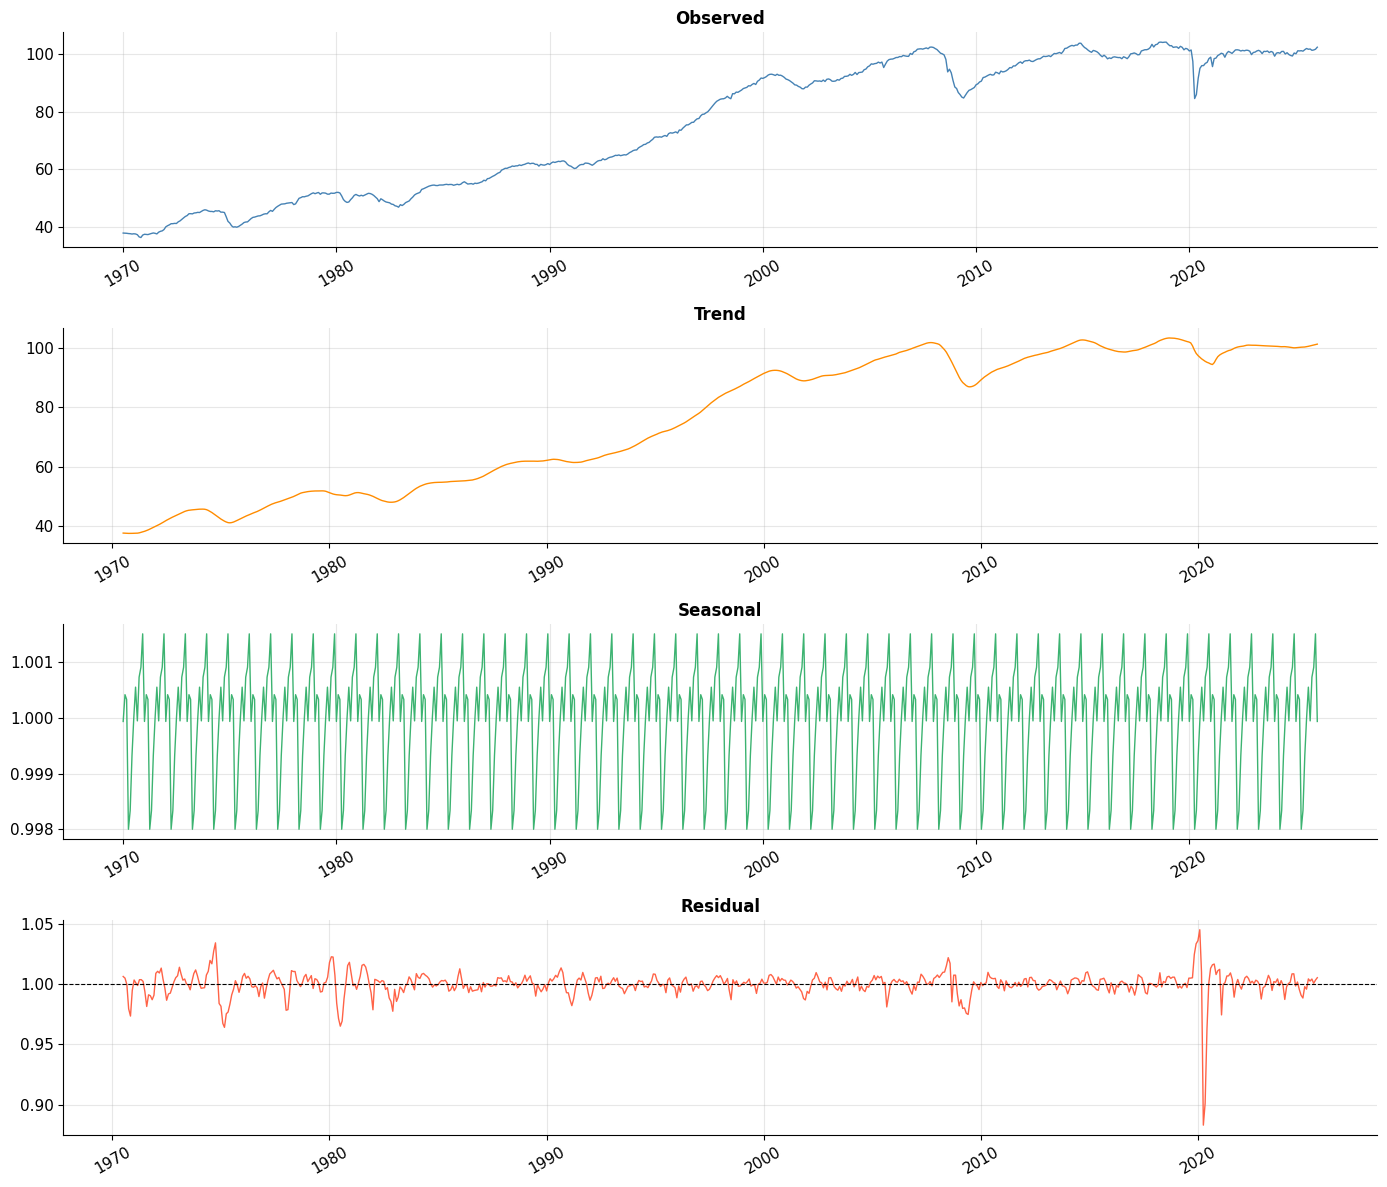

In [6]:
decomp = seasonal_decompose(df['ipi'].dropna(), model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

components = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]
labels     = ['Observed', 'Trend', 'Seasonal', 'Residual']
colors     = ['steelblue', 'darkorange', 'mediumseagreen', 'tomato']

for ax, comp, label, color in zip(axes, components, labels, colors):
    ax.plot(comp, color=color, linewidth=1)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

axes[3].axhline(1, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

In [10]:
decomp_add = seasonal_decompose(df['ipi'].dropna(), model='additive', period=12)
resid_d    = decomp_add.resid.dropna()
trend_d    = decomp_add.trend.dropna()
seasonal_d = decomp_add.seasonal

Ft = max(0, 1 - resid_d.var() / (trend_d + resid_d).var())
Fs = max(0, 1 - resid_d.var() / (seasonal_d[resid_d.index] + resid_d).var())

print("=" * 48)
print("  COMPONENTS STRENGTH (0=weak, 1=strong)")
print("=" * 48)
print(f"  Strength of the Trend:    {Ft:.4f}")
print(f"  Strength of the Seasonal: {Fs:.4f}")
print("=" * 48)


  COMPONENTS STRENGTH (0=weak, 1=strong)
  Strength of the Trend:    0.9986
  Strength of the Seasonal: 0.0119


The trend component dominates the series entirely, with a strength coefficient of *0.9986*, indicating that the trend accounts for virtually all of the systematic variation in the IPI. This is fully consistent with the strong and persistent upward trajectory. By contrast, the seasonal component is very weak, with a strength coefficient of just *0.0119*. Since seasonality is virtually absent, there is no need to resort to a seasonal ARIMA (**SARIMA**) specification and a standard ARIMA model will be sufficient to capture the dynamics of the series.

## 4. Stationarity

A fundamental requirement for ARIMA modelling is that the series must be **stationary**, that is, its mean, variance and autocovariance structure must remain constant over time. As we observed in the exploratory analysis, the IPI exhibits a clear upward trend, which is a strong indication of non-stationarity. Before proceeding with model identification and estimation, we therefore need to formally verify this property and transform the series to achieve stationarity.

To this end, we apply an hypothesis tests: the **Augmented Dickey-Fuller (ADF) test**, whose null hypothesis is that the series contains a unit root and is therefore non-stationary.

In [23]:
def run_adf(series):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"\n{'='*50}")
    print(f"                     ADF TEST     ")
    print(f"{'='*50}")
    print(f"  ADF statistic:        {result[0]:.4f}")
    print(f"  p-value:              {result[1]:.4f}")
    esit = "STATIONARITY (reject H0)" if result[1] < 0.05 else "NON STATIONARY (fail to reject H0)"
    print(f"  Conclusion:           {esit}")
    return result[1]

run_adf(ipi)


                     ADF TEST     
  ADF statistic:        -1.3064
  p-value:              0.6262
  Conclusion:           NON STATIONARY (fail to reject H0)


np.float64(0.6262299393642048)

Since the tests confirm that the original series is non-stationary, we apply a **first difference** transformation, which replaces each observation with the change from the previous month

$$\Delta x_t = x_t - x_{t-1}$$

We then re-run the ADF test on the differenced series to verify whether this transformation is sufficient to achieve stationarity, and plot the result to visually inspect the behaviour of the transformed series.

In [24]:
ipi_diff1 = ipi.diff().dropna()
run_adf(ipi_diff1)


                     ADF TEST     
  ADF statistic:        -6.8440
  p-value:              0.0000
  Conclusion:           STATIONARITY (reject H0)


np.float64(1.761754842625364e-09)

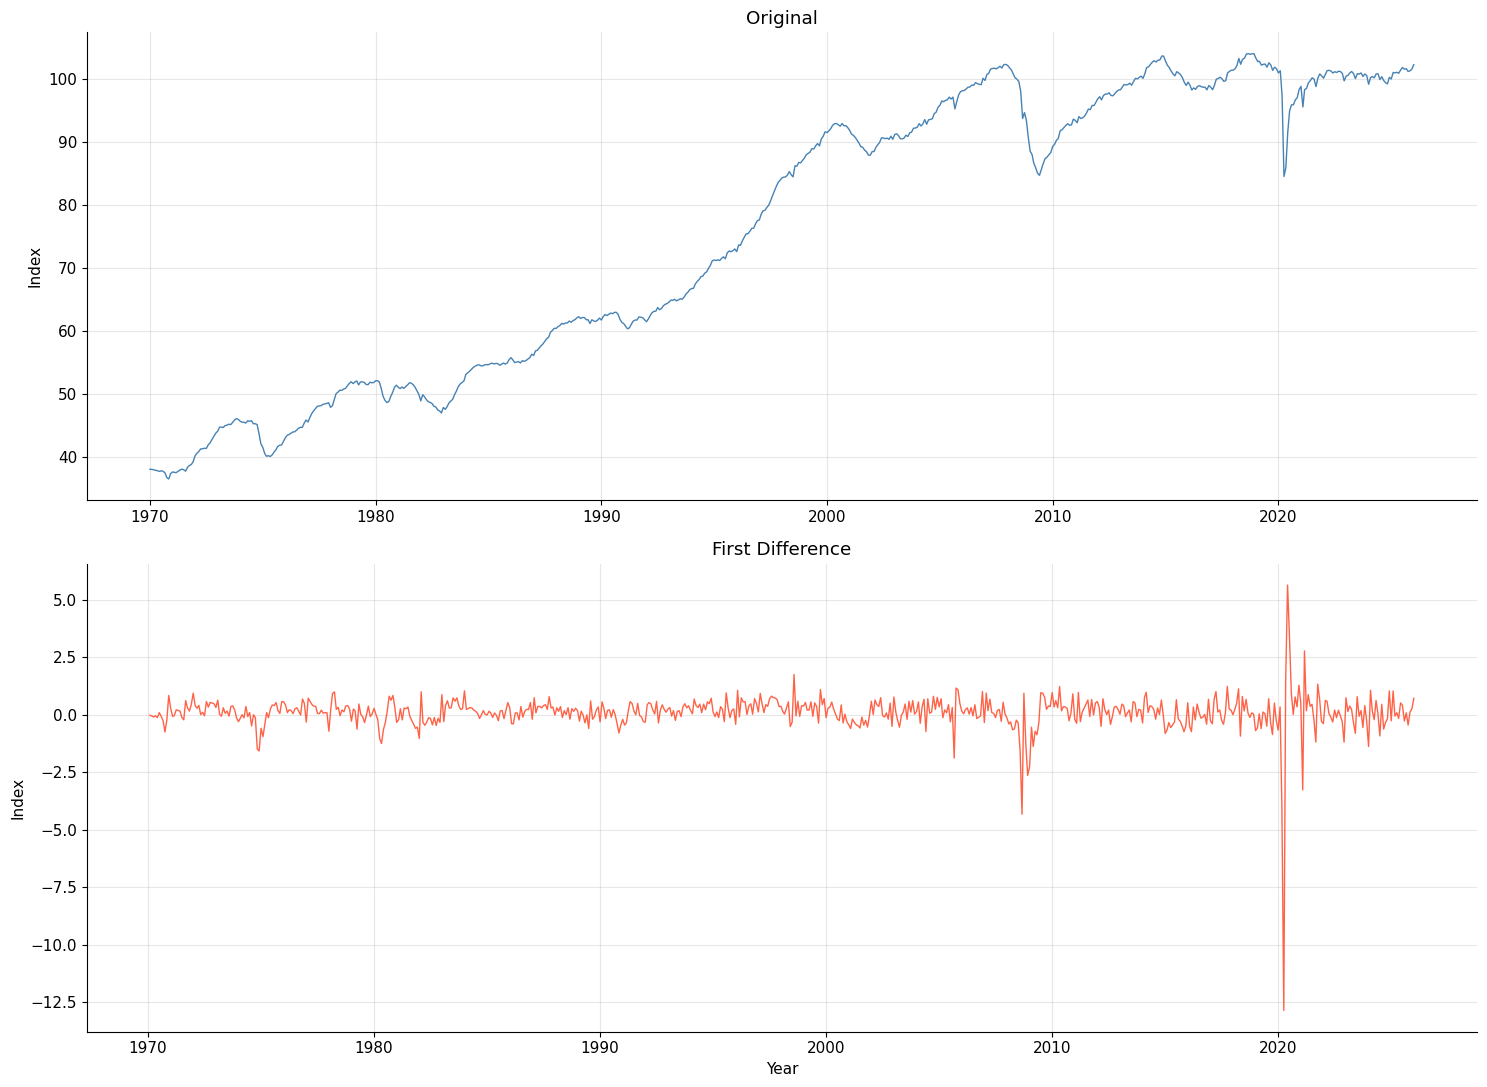

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(15, 11))

axes[0].plot(ipi, color='steelblue', linewidth=1)
axes[1].plot(ipi_diff1, color='tomato', linewidth=1)

axes[0].set_title('Original')
axes[1].set_title('First Difference')

axes[0].set_ylabel('Index')
axes[1].set_ylabel('Index')
axes[1].set_xlabel('Year')

plt.tight_layout()
plt.show()

The ADF test applied to the first-differenced series strongly rejects the null hypothesis of a unit root, confirming that the transformed series is stationary. This result is also clearly supported by the plot: the differenced series fluctuates around a constant mean of approximately zero, with no visible trend or systematic pattern. 

## 5. ARIMA Identification

Having established that the series is integrated of order one, we now turn to the identification and estimation of an ARIMA model. An ARIMA$(p, d, q)$ model is defined by three parameters: $p$, the order of the autoregressive component, $d$, the degree of differencing required to achieve stationarity and $q$, the order of the moving average component. Formally, the model can be written as:

Since we have already determined that $d = 1$, the remaining task is to identify the appropriate orders $p$ and $q$. The classical approach, proposed by *Box and Jenkins*, is to examine the **Autocorrelation Function (ACF)** and the **Partial Autocorrelation Function (PACF)** of the differenced series. The ACF measures the correlation between the series and its own lagged values, while the PACF measures the same correlation after removing the effect of all intermediate lags. The behaviour of these two functions provides direct guidance on the choice of $p$ and $q$:

- if the **PACF cuts off sharply** after lag $p$ and the ACF decays gradually, 
  a pure $AR(p)$ model is suggested
- if the **ACF cuts off sharply** after lag $q$ and the PACF decays gradually, 
  a pure $MA(q)$ model is suggested
- if **both decay gradually**, a mixed $ARMA(p,q)$ specification is appropriate


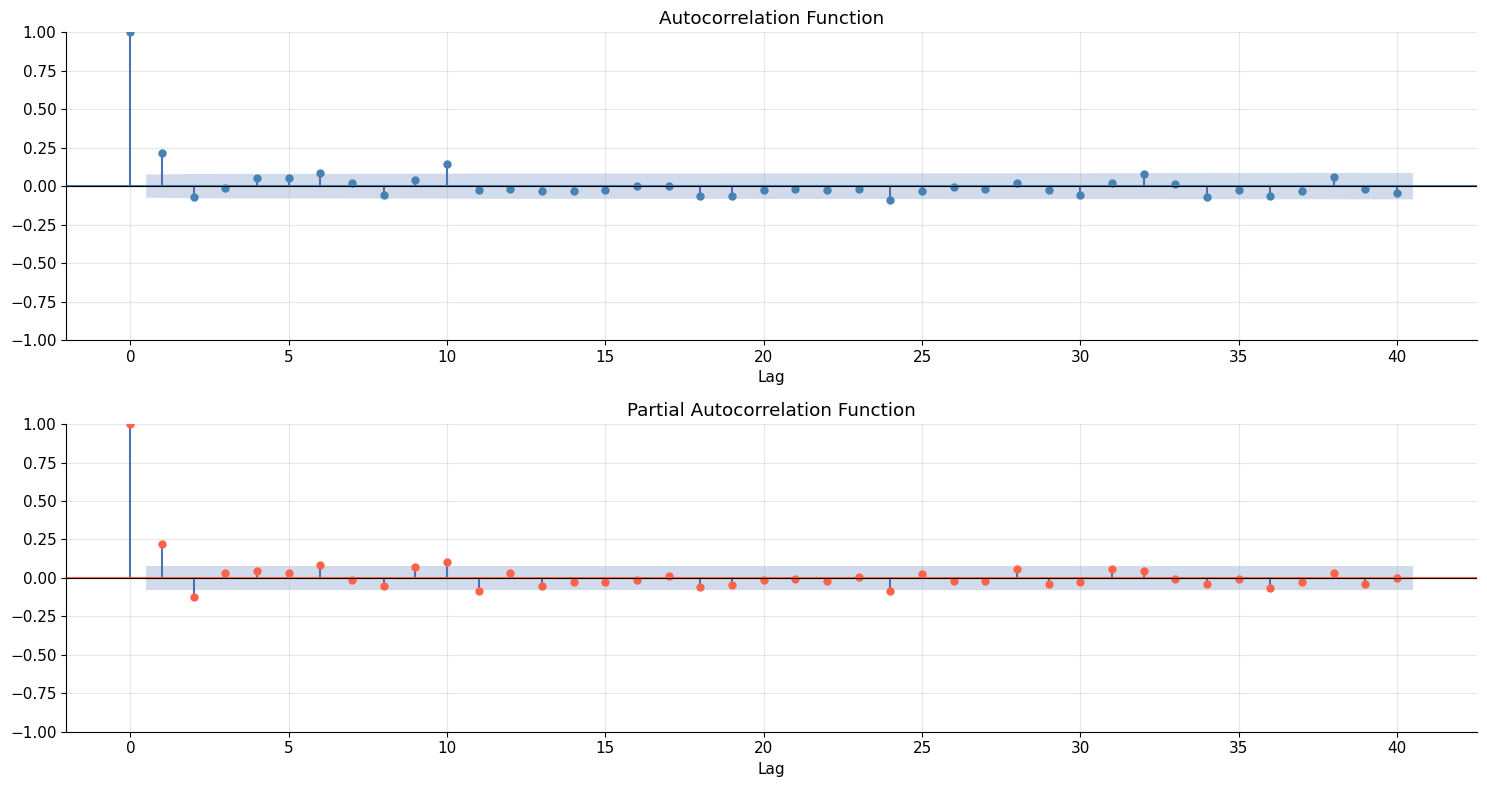

In [15]:
acf_series = ipi_diff1

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
plot_acf( acf_series, lags=40, ax=axes[0], color='steelblue',
          title='Autocorrelation Function')
plot_pacf(acf_series, lags=40, ax=axes[1], color='tomato',
          title='Partial Autocorrelation Function', method='ywm')
for ax in axes:
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Lag')
plt.tight_layout()
plt.show()

While the ACF and PACF plots provide a useful visual indication of the model order, their interpretation is often ambiguous. In our case seems that we have both the presence an autoregressive and a moving average component. 

To overcome this ambiguity and select the optimal ARIMA specification in a more rigorous and objective way, we rely on the **Akaike Information Criterion (AIC)**.

The AIC is a model selection criterion that balances goodness of fit against model complexity. It is formally defined as:

$$AIC = -2\log(\hat{L}) + 2k$$

In practice, we perform a grid search over a range of candidate orders $(p, d, q)$, estimating an ARIMA model for each combination and recording the corresponding AIC value. The optimal model is then selected as the one associated with the lowest AIC.

In [45]:
warnings.filterwarnings('ignore')

p_range = range(0, 3)
d_range = range(0, 2)
q_range = range(0, 3)

results_list = []

for p, d, q in itertools.product(p_range, d_range, q_range):
    try:
        fit_tmp = ARIMA(ipi, order=(p, d, q)).fit()
        results_list.append({'p': p, 'd': d, 'q': q,
                             'AIC': round(fit_tmp.aic, 2),
                             'BIC': round(fit_tmp.bic, 2)})
    except:
        pass

results_df = pd.DataFrame(results_list).sort_values('AIC').reset_index(drop=True)
print(results_df.head(10).to_string(index=False))

best_p = int(results_df.iloc[0]['p'])
best_d = int(results_df.iloc[0]['d'])
best_q = int(results_df.iloc[0]['q'])

 p  d  q     AIC     BIC
 0  1  1 1559.86 1568.88
 0  1  2 1560.35 1573.88
 2  1  0 1560.41 1573.94
 2  1  2 1560.62 1583.17
 1  1  1 1560.66 1574.19
 2  1  1 1561.67 1579.71
 1  1  2 1562.22 1580.27
 1  1  0 1567.56 1576.58
 1  0  1 1573.42 1591.47
 1  0  2 1573.93 1596.49


The grid search results indicate that the best performing model according to the AIC criterion is the **ARIMA(0, 1, 1)**, which achieves the lowest AIC value. This result is consistent with the inspection of the ACF and PACF plots carried out in the previous section.

We now estimate the ARIMA(0, 1, 1) model on the full sample. The model can be written explicitly as:

$$x_t = c  + \varepsilon_t + \theta_1 \varepsilon_{t-1}$$

where $\theta_1$ is the moving average coefficient, $c$ is a constant term and $\varepsilon_t$ is a white noise process (the error term). The parameters are estimated by *Maximum Likelihood Estimation (MLE)*. 

In [49]:
order = (best_p, best_d, best_q)

model_final = ARIMA(ipi, order=order)
fit_final = model_final.fit()
print(fit_final.summary())

                               SARIMAX Results                                
Dep. Variable:                    ipi   No. Observations:                  673
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -777.929
Date:                Thu, 30 Apr 2026   AIC                           1559.859
Time:                        09:39:42   BIC                           1568.879
Sample:                    01-01-1970   HQIC                          1563.352
                         - 01-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.2735      0.009     30.544      0.000       0.256       0.291
sigma2         0.5929      0.006    100.488      0.000       0.581       0.604
Ljung-Box (L1) (Q):                   0.35   Jarque-

All parameters are statistically significant at the 1% level, as confirmed by the very low p-values. The moving average coefficient is positive and significant, indicating that past forecast errors contribute meaningfully to the current value of the series. 

The **Ljung-Box test** indicates that we cannot reject the null hypothesis of no autocorrelation in the residuals, confirming that the model has captured the linear dynamics of the series. However, the **Jarque-Bera test** strongly rejects normality and the residuals display extreme skewness and very high kurtosis, suggesting the presence of heavy tails and large **outliers**. Furthermore, the **heteroskedasticity** test strongly rejects constant variance, suggesting the presence of conditional heteroskedasticity in the residuals.

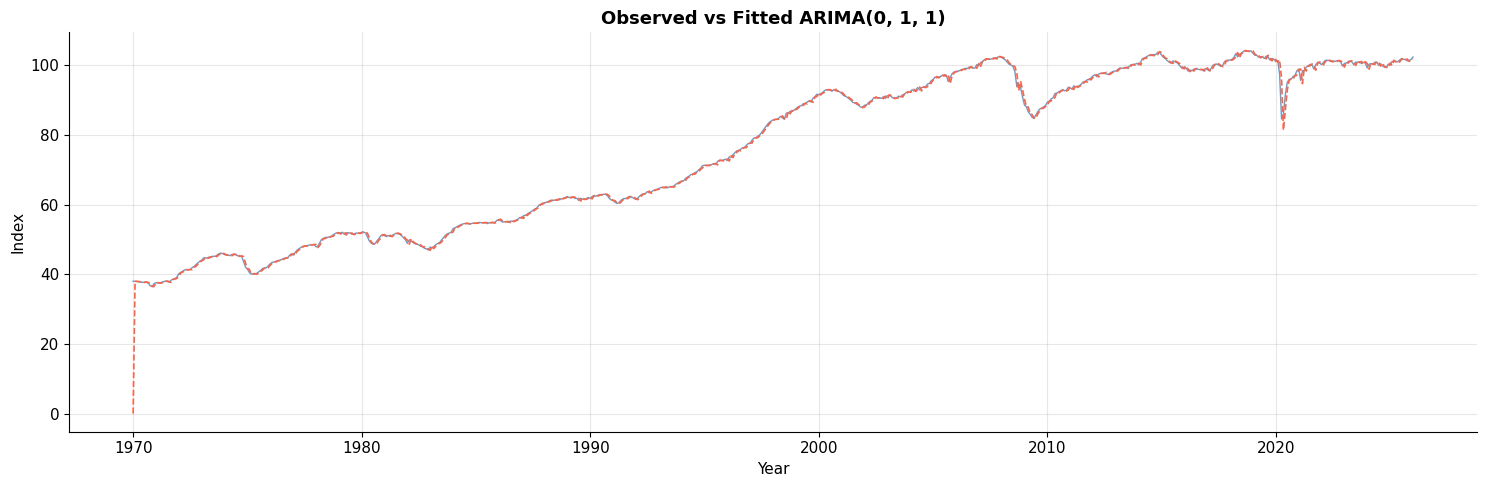

In [51]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(ipi, color='steelblue', linewidth=1, alpha=0.8, label='Observed')
ax.plot(fit_final.fittedvalues, color='tomato', linewidth=1.2,
        linestyle='--', label=f'ARIMA{order} Fitted')
ax.set_title(f'Observed vs Fitted ARIMA{order}', fontsize=13, fontweight='bold')
ax.set_ylabel('Index')
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

The plot shows that the fitted values of the ARIMA(0, 1, 1) model perfectly overlap with the observed series. The model fits the data well in-sample not because it has captured meaningful structure, but simply because it is exploiting the strong persistence of the series.

## 6. Forecasting

The **forecast** is produced by iterating the estimated model forward in time, using the last observed values of the series as starting conditions. Along with the point forecast, we compute a 95% confidence interval, which provides a measure of the uncertainty surrounding each predicted value. The model tends to project the series forward in a smooth and persistent manner, closely following the level of the last observed value. This means that the point forecast will largely reflect the recent trajectory of the IPI.

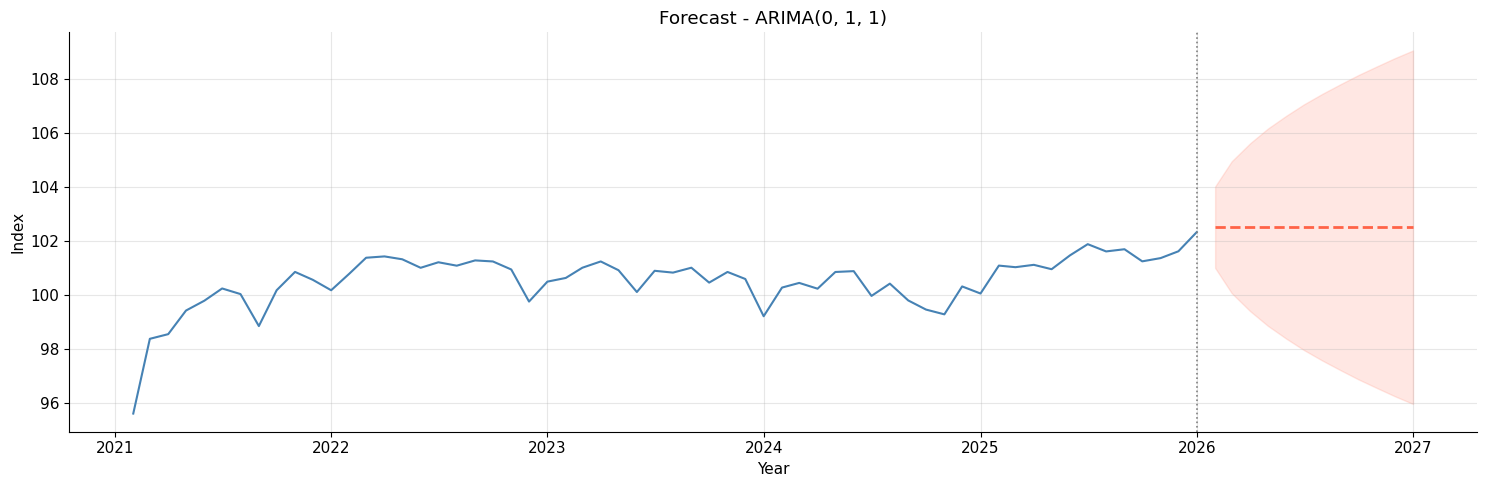

In [56]:
n_forecast = 12

forecast = fit_final.get_forecast(steps=n_forecast)
forecast_mean = fc.predicted_mean
forecast_ci = fc.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(ipi.iloc[-60:], color='steelblue', linewidth=1.5, label='Observed')
ax.plot(fc_mean, color='tomato', linewidth=2, linestyle='--', label='Forecast')
ax.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                color='tomato', alpha=0.15, label='95% CI')
ax.axvline(x=ipi.index[-1], color='gray', linestyle=':', linewidth=1.2, label='Forecast Start')
ax.set(title=f'Forecast - ARIMA{order}', ylabel='Index', xlabel='Year')
plt.tight_layout()
plt.show()

## 7. Residuals Analysis

The final step of the *Box-Jenkins* methodology consists in the analysis of the **model residuals**, the differences between the observed values of the series and the fitted values produced by the estimated ARIMA model. This step is fundamental because the quality of a time series model cannot be assessed only on the basis of its fit. A well-specified ARIMA model should produce residuals that behave as **white noise**, a sequence of uncorrelated random variables with zero mean, constant variance and normal distribution. If any of these properties is violated, it indicates that the model has left some systematic structure in the data and that a more appropriate specification should be considered.

To formally assess the properties of the residuals, we conduct four diagnostic tests:

- the **Ljung-Box test** checks for the presence of residual autocorrelation;
- the **Jarque-Bera** assess if the residuals follow a normal distribution;
- the **Shapiro-Wilk tests**, again, assess if the residuals follow a normal distribution; 
- the **t-test** verifies if the mean of the residuals is not significantly different from zero.

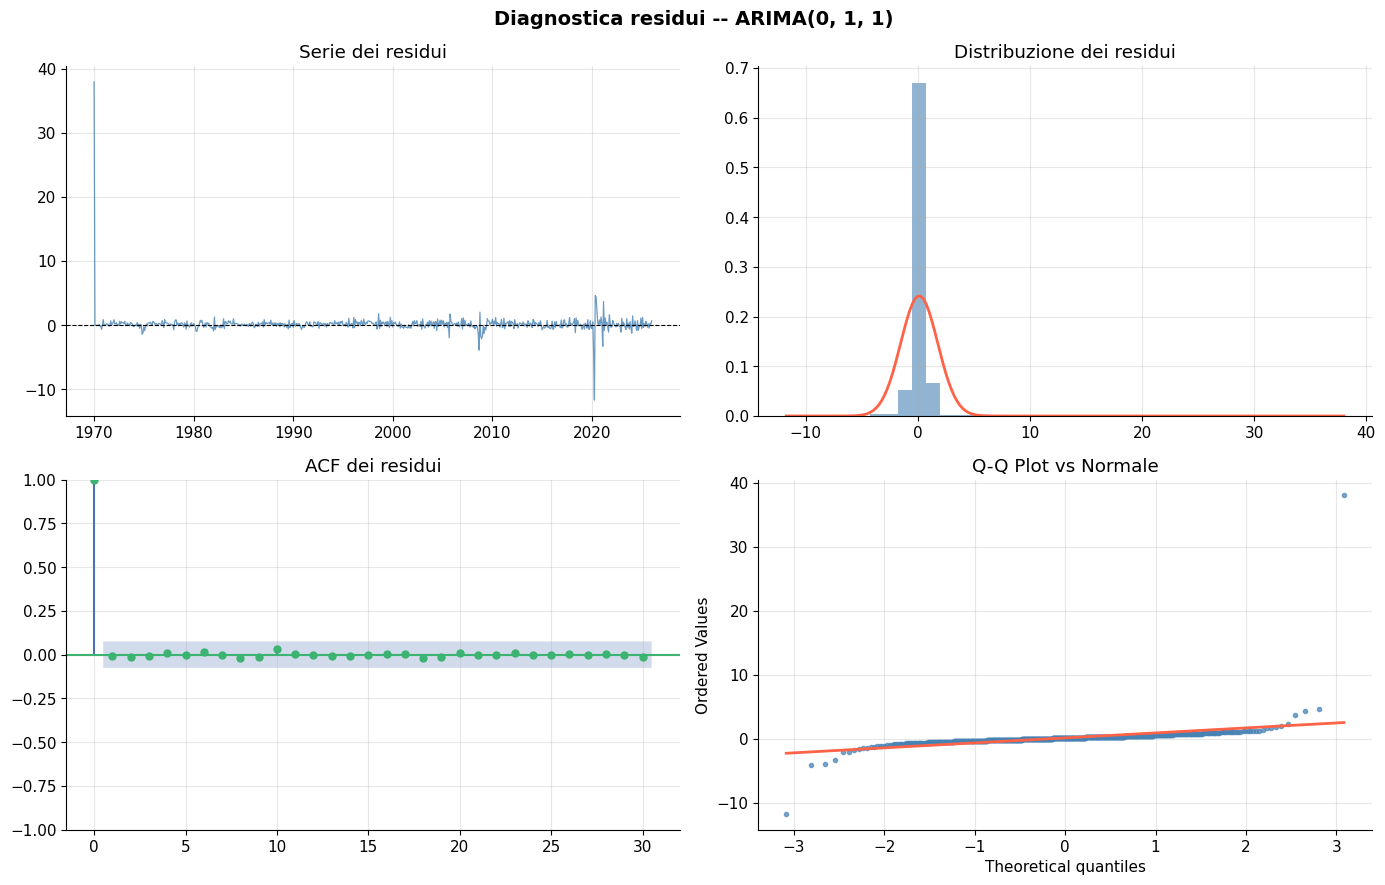

In [ ]:
residuals = fit_final.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f'Diagnostica residui -- ARIMA{order}', fontsize=14, fontweight='bold')

axes[0, 0].plot(residuals, color='steelblue', linewidth=0.9, alpha=0.8)
axes[0, 0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0, 0].set_title('Residuals')

mu, sigma = residuals.mean(), residuals.std()
x_norm = np.linspace(residuals.min(), residuals.max(), 200)
axes[0, 1].hist(residuals, bins=40, color='steelblue', alpha=0.6, density=True)
axes[0, 1].plot(x_norm, stats.norm.pdf(x_norm, mu, sigma), color='tomato', linewidth=2)
axes[0, 1].set_title('Residuals Distribution')

plot_acf(residuals.dropna(), lags=30, ax=axes[1, 0], color='mediumseagreen',
         title='Residuals ACF')

stats.probplot(residuals.dropna(), dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot vs Normal')
axes[1, 1].get_lines()[0].set(color='steelblue', markersize=3, alpha=0.7)
axes[1, 1].get_lines()[1].set(color='tomato', linewidth=2)

plt.tight_layout()
plt.show()

In [61]:
print("=" * 65)
print("              RESIDUALS STATISTICAL TESTS       ")
print("=" * 65)

lb = acorr_ljungbox(residuals.dropna(), lags=[10, 20], return_df=True)
print("\nLJUNG-BOX")
print(f"  {'Lag':<8} {'Statistic':<16} {'p-value':<12} {'Result'}")
for lag_val, row in lb.iterrows():
    result = "White Noise" if row['lb_pvalue'] > 0.05 else "Autocorrelation"
    print(f"  {lag_val:<8} {row['lb_stat']:<16.4f} {row['lb_pvalue']:<12.4f} {result}")

jb_stat, jb_p = stats.jarque_bera(residuals.dropna())
print(f"\nJARQUE-BERA")
print(f"  Statistic: {jb_stat:.4f} | p-value: {jb_p:.4f}")
print(f"  Result   : {'Normality not rejected' if jb_p > 0.05 else 'Non-normality (a=5%)'}")

sample_r = residuals.dropna().sample(min(500, len(residuals.dropna())), random_state=42)
sw_stat, sw_p = stats.shapiro(sample_r)
print(f"\nSHAPIRO-WILK")
print(f"  Statistic: {sw_stat:.4f} | p-value: {sw_p:.4f}")
print(f"  Result   : {'Normality not rejected' if sw_p > 0.05 else 'Non-normality (a=5%)'}")

t_stat, t_p = stats.ttest_1samp(residuals.dropna(), 0)
print(f"\nT-TEST")
print(f"  Mean: {residuals.mean():.6f} | t={t_stat:.4f} | p-value: {t_p:.4f}")
print(f"  Result : {'Mean ≈ 0' if t_p > 0.05 else 'Mean ≠ 0 (a=5%)'}")

print("\n" + "=" * 65)

              RESIDUALS STATISTICAL TESTS       

LJUNG-BOX
  Lag      Statistic        p-value      Result
  10       1.5380           0.9988       White Noise
  20       2.0891           1.0000       White Noise

JARQUE-BERA
  Statistic: 4844981.7967 | p-value: 0.0000
  Result   : Non-normality (a=5%)

SHAPIRO-WILK
  Statistic: 0.2160 | p-value: 0.0000
  Result   : Non-normality (a=5%)

T-TEST
  Mean: 0.131746 | t=2.0709 | p-value: 0.0387
  Result : Mean ≠ 0 (a=5%)



The *Ljung-Box test* fails to reject the null hypothesis of no autocorrelation. The residuals show no sign of remaining linear dependence, confirming that the ARIMA(0, 1, 1) has successfully captured the autocorrelation structure of the series.

The *Jarque-Bera* and *Shapiro-Wilk* tests both strongly reject the null hypothesis of normality. The Jarque-Bera reflects the extreme kurtosis and skewness and points to the presence of very large outliers in the residuals. The Shapiro-Wilk confirms this finding. These extreme values are most likely driven by the sharp contractions observed around the Global Financial Crisis and the COVID-19, which generated residuals far outside the range expected.

The *T-test* on the mean of the residuals is virtually zero and indicates that the model produces unbiased predictions on average.

## Conclusions

This work has presented a complete empirical analysis of the US Industrial Production Index, following the classical *Box-Jenkins* methodology for time series modelling. The series was first made stationary — a fundamental step in time series analysis — before identifying the most appropriate ARIMA specification. The empirical results indicate that the IPI is best described by an **ARIMA(0, 1, 1)** model.

This model captures the underlying trend of the series reasonably well; however, some ambiguities remain regarding its overall adequacy. In econometrics, this is not uncommon: when working with real-world time series, the best model cannot be determined a priori. In this specific case, the ARIMA(0, 1, 1) may not represent the optimal specification and further approaches could be explored to improve analytical precision. In particular, the forecasting results should be interpreted with caution, as they may be negatively affected by dynamics not accounted for by the current model.

To address these limitations, several extensions could be considered. First, a **(G)ARCH model** could be employed to explicitly account for the time-varying heteroskedasticity observed in the residuals, this alone might be sufficient to produce a more reliable analysis. A further refinement would be to formally test for structural breaks associated with major economic shocks and incorporate them through **regime-switching** specifications.

Overall, the analysis yields satisfactory results. The selected model captures the broad dynamics of the series and the residual diagnostics confirm that the next natural step would be to extend the framework with a GARCH-type model to better account for the volatility structure of the residuals.